In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
import json
import random
import argparse
from TrackReconstruction_functions import *
from sklearn.neighbors import BallTree
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
input_file = "/mnt/d/events_45_135/simulated_data/1bar/5.0percent/events_45_135_5.0percent_smear_773.h5"
pressure = 1
diffusion = "5.0percent"
event_type = "events_45_135"
file_identify = f"{event_type}_{pressure}_{diffusion}"
hits_df = pd.read_hdf(input_file, "MC/hits")
part_df = pd.read_hdf(input_file, "MC/particles")

In [3]:
hits_df.head()

,event_id,x,y,z,energy
0,92880,-2601.023193,215.695572,5532.705566,0.000025
1,92880,-2612.230225,224.622894,5538.957031,0.000050
2,92880,-2599.706543,203.655365,5540.999512,0.000025
3,92880,-2615.195801,218.778732,5543.737793,0.000025
4,92880,-2602.740479,228.412430,5544.097168,0.000050


In [4]:
def get_vertex(part_df, eid):
    row = part_df[
        (part_df.event_id == eid) & (part_df.particle_id == 1)
    ].iloc[0]
    return row.initial_x, row.initial_y, row.initial_z

In [5]:
def get_zshift(pressure):
    density = 5.987*pressure
    M = 1000/0.9
    det_size = 1000*np.cbrt((4 * M) / (np.pi * density))/2.0

    return det_size

z_shift = get_zshift(pressure)

In [6]:
def get_split():
    r= random.random()
    if r < 0.7:
        return 'train'
    elif r < 0.9:
        return 'val'
    else:
        return 'test'

In [17]:
def get_node_centers_df(hits_df, eid, pressure, diffusion):
    data = hits_df[hits_df["event_id"] == int(eid)].copy()
    if np.isnan(data.z.mean()) or data.z.empty:
        print(f"Skipping event {eid} because hits are missing or invalid")
        return pd.DataFrame()
    Diff_smear, energy_threshold, diff_scale_factor, radius_sf, group_sf, Tortuosity_dist, voxel_size, det_size  = InitializeParams(pressure, diffusion)

    if (diffusion == "nodiff"):
        mean_sigma=10/np.sqrt(pressure)
    else:
        if data.z.mean() < 0:
            print("skipping event, invalid data.z.mean()")
            return None, None
        mean_sigma = diff_scale_factor*Diff_smear*np.sqrt(0.1*data.z.mean())

    # The expected diffusion is less than vox size so replace
    if (mean_sigma < 1.5*voxel_size):
        mean_sigma = 1.5*voxel_size

    #if diffusion != "nodiff":
        #mean_sigma = mean_sigma * 1.3 ### ADJUST!
    
    # Create the bins ---- 
    xbw  = mean_sigma
    xmin = -det_size - mean_sigma/2 
    xmax = det_size  + mean_sigma/2
    
    ybw  = mean_sigma
    ymin = -det_size - mean_sigma/2 
    ymax = det_size  + mean_sigma/2
    
    # This shifts the z pos of the events so 0 is at anode
    # can set this to zero
    #z_shift = det_size
    z_shift = 0
    
    zbw=mean_sigma
    zmin=-det_size + z_shift - mean_sigma/2 
    zmax=det_size + z_shift + mean_sigma/2

    # bins for x, y, z
    xbins = np.arange(xmin, xmax+xbw, xbw)
    ybins = np.arange(ymin, ymax+ybw, ybw)
    zbins = np.arange(zmin, zmax+zbw, zbw)
    
    # center bins for x, y, z
    xbin_c = xbins[:-1] + xbw / 2
    ybin_c = ybins[:-1] + ybw / 2
    zbin_c = zbins[:-1] + zbw / 2

    # If there are overlapping voxels, merge them. Otherwise the energy gets messed up
    data = (data.groupby(["event_id", "x", "y", "z"], as_index=False)["energy"].sum())
    # then sort it based on the x,y,z
    data = data.sort_values(by=['x', "y", "z"]).reset_index(drop=True)
    
    # Apply grouping
    data_copy = data.copy()
    #df_merged = CutandRedistibuteEnergy(data_copy, energy_threshold)
    print("applied grouping")

    if (diffusion == "nodiff"):
        mean_sigma_group=15
    else:
        mean_sigma_group = group_sf*Diff_smear*np.sqrt(0.1*data.z.mean())

    if (mean_sigma_group < voxel_size/2.0):
        mean_sigma_group = voxel_size/2.0

    df_merged = GroupHits(data_copy, mean_sigma_group)

    # Apply clustering
    node_centers_df = []
    energy_gid_dict = {}
    
    for gid in sorted(df_merged.group_id.unique()):
        temp_df = df_merged[df_merged.group_id == gid]
        energy_sum = temp_df["energy"].sum()
        energy_gid_dict[gid] = energy_sum
        temp_df.reset_index(drop=True, inplace=True)
        node_centers_df.append(Cluster(temp_df, mean_sigma))
        
    max_energy_gid = max(energy_gid_dict, key=energy_gid_dict.get)
    node_centers_df = pd.concat(node_centers_df, ignore_index=True)
    node_centers_df = node_centers_df[node_centers_df.group_id == max_energy_gid]

    return node_centers_df


In [8]:
def nearest_neighbors(XC, YC):
    coords = np.column_stack([XC, YC])
    tree = BallTree(coords) #create spatial index
    centroid = coords.mean(axis=0) #find avg position of all hits
    dists = np.linalg.norm(coords - centroid, axis=1)
    start = np.argmax(dists) #start at furthest dist
    
    route = [start]
    visited = set([start])
    while len(visited) < len(coords): # go until every point is visited
        current = route[-1] # last point added to route is current position
        _, indices = tree.query([coords[current]], k=len(coords)) # queries all points sorted by dist
        # take nearest unvitited point and add to route
        for idx in indices[0]:
            if idx not in visited:
                route.append(idx)
                visited.add(idx)
                break
    return np.array(route)

In [9]:
def PlotEvent3D(hits, part, eid, z_shift, pressure, diffusion):
    fig = plt.figure(figsize=(5.12, 5.12), dpi=100)


    event_hits = hits[hits.event_id == eid].copy()
    clustered_hits = get_node_centers_df(hits, eid, pressure, diffusion)

    if diffusion != "nodiff":
        event_hits["z"] = event_hits["z"] - z_shift
        clustered_hits["z"] = clustered_hits["z"] - z_shift
        
    part = part[(part.event_id == eid) & (part.primary == 1)]
    x_vertex, y_vertex, z_vertex = get_vertex(part, eid)
    
    # Create 3D axes
    ax = fig.add_subplot(111, projection='3d')

    fig.set_facecolor('white')
    ax.set_facecolor('white')

    # Scatter plot in 3D
    sc = ax.scatter(event_hits.x, event_hits.y, event_hits.z, 
                    c=event_hits.energy, cmap='Spectral', s=10, label="Reco hits")
    
    ver = ax.scatter(x_vertex, y_vertex, z_vertex, s=50, color="black")

    ax.set_xlabel("X [mm]", fontsize=15, color='black')
    ax.set_ylabel("Y [mm]", fontsize=15, color='black')
    ax.set_zlabel("Z [mm]", fontsize=15, color='black')

    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')
    ax.zaxis.label.set_color('black')
    ax.tick_params(axis='x', colors='black')
    ax.tick_params(axis='y', colors='black')
    ax.tick_params(axis='z', colors='black')

    ax.grid(False)

    # Add colorbar
    cbar = fig.colorbar(sc, ax=ax, shrink=0.5, aspect=10, pad=0.09)
    cbar.set_label("Energy", fontsize=12, color='black')
    cbar.ax.yaxis.set_tick_params(color='black')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='black')

    # Remove background panes
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    # extract raw data arrays
    x = event_hits.x.values
    y = event_hits.y.values
    z = event_hits.z.values
    c = event_hits.energy.values

    xc = clustered_hits.x.values
    yc = clustered_hits.y.values
    zc = clustered_hits.z.values

    plt.close(fig)


    return (x, y, z, c), (xc, yc, zc), (x_vertex, y_vertex, z_vertex)

In [28]:
def compute_angle(pi, hx, hy, XC, YC, min_dist):
    if pi <= 0 or pi >= len(XC) - 1:
        return np.pi
    
    i_left = pi - 1
                
    while i_left > 0 and np.sqrt((XC[i_left]-hx)**2 + (YC[i_left]-hy)**2) < min_dist:
        i_left -= 1
    
    i_right = pi + 1
    
    while i_right < len(XC)-1 and np.sqrt((XC[i_right]-hx)**2 + (YC[i_right]-hy)**2) < min_dist:
        i_right += 1

    #getting the vectors and angle
    v1 = np.array([XC[i_left] - XC[pi], YC[i_left] - YC[pi]])
    v2 = np.array([XC[i_right] - XC[pi], YC[i_right] - YC[pi]])
    norm_product = np.linalg.norm(v1) * np.linalg.norm(v2)
    if norm_product == 0:
        return np.pi
    cos_theta = np.dot(v1, v2) / norm_product
    cos_theta = np.clip(cos_theta, -1, 1) 
    theta = np.arccos(cos_theta)
    
    return theta

In [35]:
def get_data(XYZC, clustered_xyz, vertex, eid, file_identify, split):
    x, y, z, c = XYZC
    x_vertex, y_vertex, z_vertex = vertex
    xc, yc, zc = clustered_xyz

    projections = [("xy", x, y, xc, yc, x_vertex, y_vertex),
                   ("yz", y, z, yc, zc, y_vertex, z_vertex),
                   ("xz", x, z, xc, zc, x_vertex, z_vertex)]
    
    w = h = 0.02 #bounding box size

    #initializing:
    
    axis_limits = {} 

    dedup_radius = 30 if diffusion != "nodiff" else 20
                    
#__________________________________________________________________________________________________________________

# Go through each projection:
    
    for dim, X, Y, XC, YC, vx, vy in projections:
        
        #initialize paths
        img_filename = f"event_{eid}_{file_identify}_{dim}_{split}.png"
        label_filename = f"event_{eid}_{file_identify}_{dim}_{split}.txt"

        #plot the event
        fig, ax = plt.subplots(figsize=(5.12, 5.12), dpi=100)
        ax.scatter(X, Y, c=c, cmap="Spectral", s=5, alpha=.1)

        order = nearest_neighbors(XC, YC) # ordering the hits based on the shortest path to go through all the hits
        XC = XC[order]
        YC = YC[order]
        sharp_angles = []
        colors = plt.cm.plasma(np.linspace(0, 1, len(XC)))
        
#___________________________________________________________________________________________________________________
        
# Loop over clustered hits
        
        for i, (hx, hy) in enumerate(zip(XC, YC)):
            ax.scatter(hx, hy, color=colors[i], s=7, alpha=.7) #plot for the CLUSTERED hits
            if i == 0 or i == len(XC) - 1:
                sharp_angles.append([hx, hy, i, 10]) #adding endpoints as a false vertex

            else:
                if diffusion == "nodiff":
                    density_radius = 15 #define a region to get the density of points
                else:
                    density_radius = 15
                    
                neighbors = np.sum(np.sqrt((XC - hx)**2 + (YC - hy)**2) < density_radius)

                # Specifications:
                
                min_dist = max(10, neighbors * 2)  # denser = need to go further
                if neighbors > 15:        # dense/curly — be strict, only very sharp turns
                    max_angle_threshold = np.pi / 3   # 60°
                elif neighbors > 6:
                    max_angle_threshold = np.pi / 2   # 90°
                else:
                    max_angle_threshold = 2 * np.pi / 3  # 120°
                
                min_angle_threshold = 0  # always allow sharpest angles

                theta = compute_angle(i, hx, hy, XC, YC, min_dist)

                smallest_angle=True
                dist_to_vertex = np.sqrt((hx - vx)**2 + (hy - vy)**2)
                
#____________________________________________________________________________________________________________________
                
# getting rid of any points that are too close by choosing the sharpest angle
                
                for j, point in enumerate(sharp_angles):
                    px, py, pi = point[0], point[1], point[2] 
                    dist_to_point = np.sqrt((hx - point[0])**2 + (hy - point[1])**2)
                    neighbors_pi = np.sum(np.sqrt((XC - px)**2 + (YC - py)**2) < density_radius)
                    
                    if diffusion == "nodiff":
                        min_dist_pi = max(10, neighbors_pi * 2)
                    else:
                        min_dist_pi = max(65, neighbors_pi * 3)
                        
                    if dist_to_point < min_dist_pi:
                        px, py, pi = point[0], point[1], point[2]

                        if pi == 0 or pi == len(XC) - 1: #keep end points no matter what
                            break
                            
                        theta_new = compute_angle(pi, px, py, XC, YC, min_dist)
                        
                        if theta < theta_new:
                            sharp_angles.pop(j)

                        else:
                            smallest_angle = False
                        break

                if (min_angle_threshold <= theta <= max_angle_threshold) and (dist_to_vertex > 15) and smallest_angle:
                    sharp_angles.append([hx, hy, i, min_dist])

# another check because the previous loop kept missing some 
        
        cleaned = []
        for pt in sharp_angles:
            too_close = False
            for kept in cleaned:
                dist = np.sqrt((pt[0]-kept[0])**2 + (pt[1]-kept[1])**2)
                if dist < dedup_radius:
                    # keep sharpest
                    if compute_angle(pt[2], pt[0], pt[1], XC, YC, pt[3]) < compute_angle(kept[2], kept[0], kept[1], XC, YC, kept[3]):
                        cleaned.remove(kept)
                    else:
                        too_close = True
                    break
            if not too_close:
                cleaned.append(pt)
        sharp_angles = cleaned   

        #plotting
        ax.scatter(vx, vy, color="black", s=10)
        for i in sharp_angles:
            ax.scatter(i[0], i[1], color="blue", s=10)

        ax.axis("off") #don't show axis

#___________________________________________________________________________________________________________________________________

# Get axis limits

        xlim = ax.get_xlim()
        ylim = ax.get_ylim()

        # Expand limits if vertex is outside current limits
        if vx < xlim[0]:
            xlim = (vx, xlim[1])
        if vx > xlim[1]:
            xlim = (xlim[0], vx)
        if vy < ylim[0]:
            ylim = (vy, ylim[1])
        if vy > ylim[1]:
            ylim = (ylim[0], vy)

        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

        axis_limits[dim] = {"xlim": list(xlim), "ylim": list(ylim)}

        plt.show()
        
        """


        #normalize for yolo (0-1)
        cx = (vx - xlim[0]) / (xlim[1] - xlim[0]) # dist from left / total width
        cy = 1 - ((vy - ylim[0]) / (ylim[1] - ylim[0])) # subtract from 1 since y=0 is at top in yolo

        # check if normalized coordinates are valid
        if not (0 <= cx <= 1) or not (0 <= cy <= 1):
            print(f"Skipping event {eid} due to out-of-bounds normalized coordinates: cx={cx}, cy={cy}")
            return (None, None, None)


        print(f"label: 0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")
        #save label
        with open(label_filename, "w") as f:
            f.write(f"0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")
        
        #save plot
        fig.savefig(img_filename, bbox_inches="tight", pad_inches=0)

        plt.close(fig)

    return x_vertex, y_vertex, z_vertex, axis_limits
        """

In [36]:
plt.close()

Processing event 92880
applied grouping
PlotEvent3D done


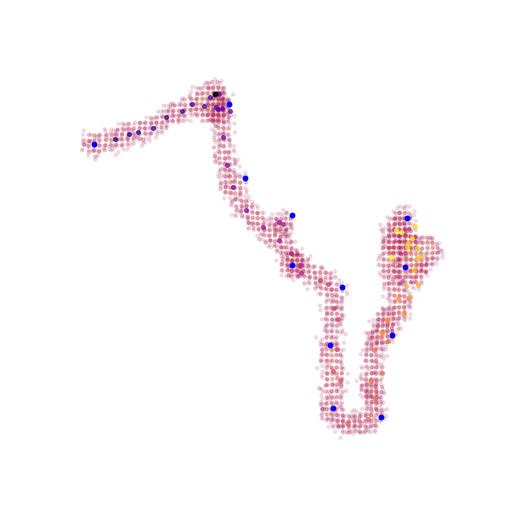

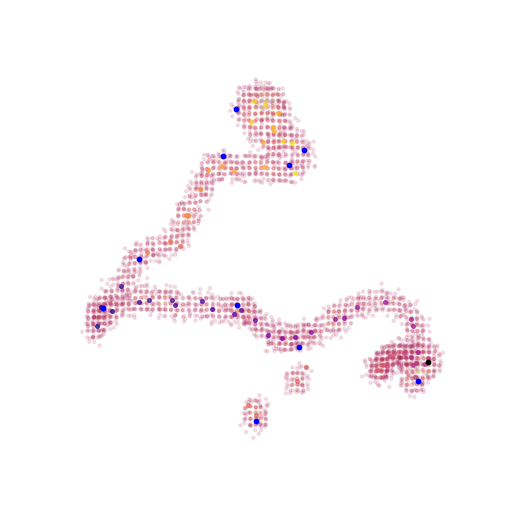

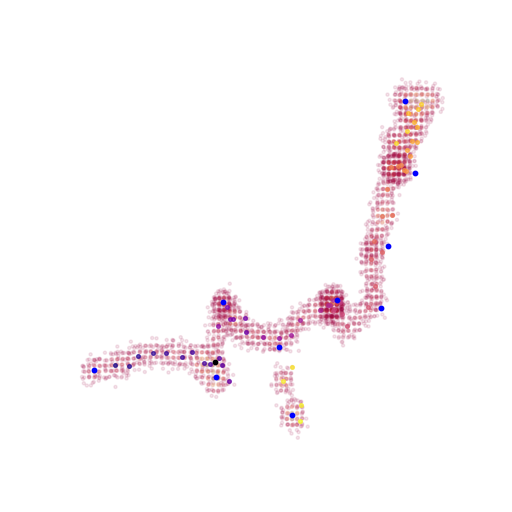

get_data done
Processing event 92881
applied grouping
PlotEvent3D done


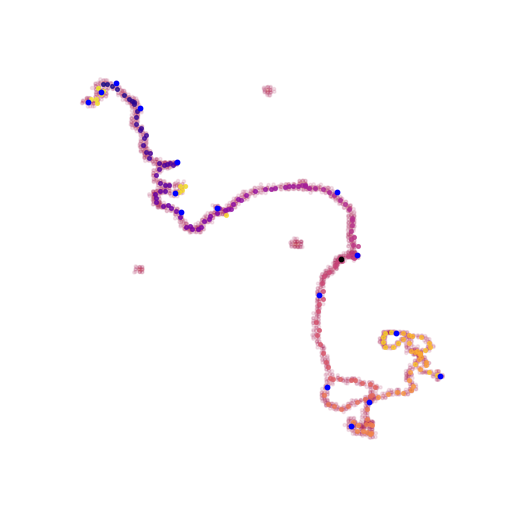

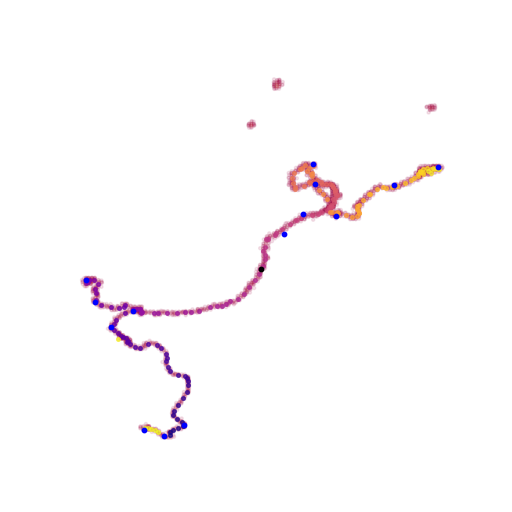

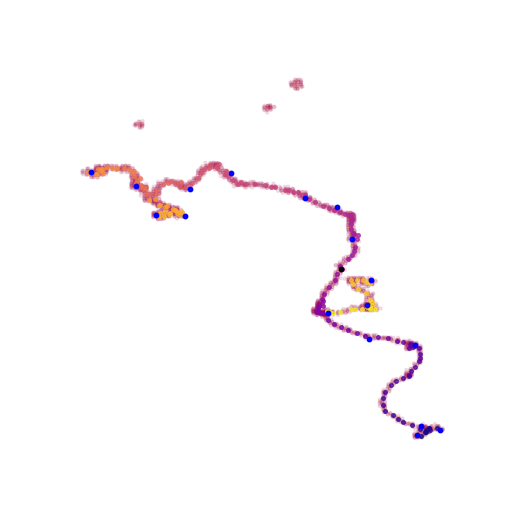

get_data done
Processing event 92882
applied grouping
PlotEvent3D done


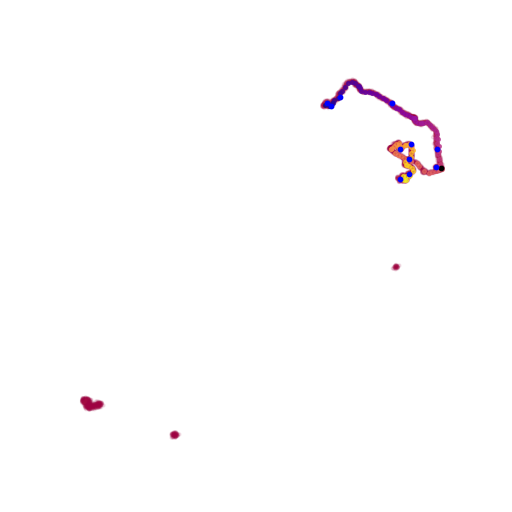

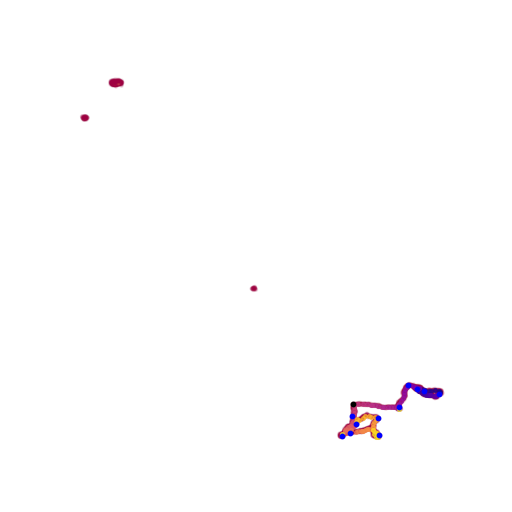

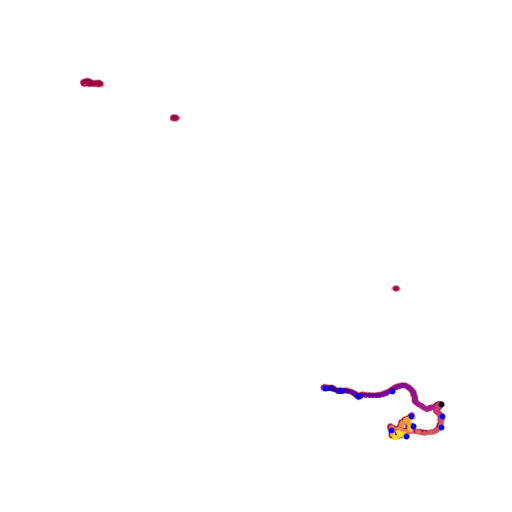

get_data done
Processing event 92883
applied grouping
PlotEvent3D done


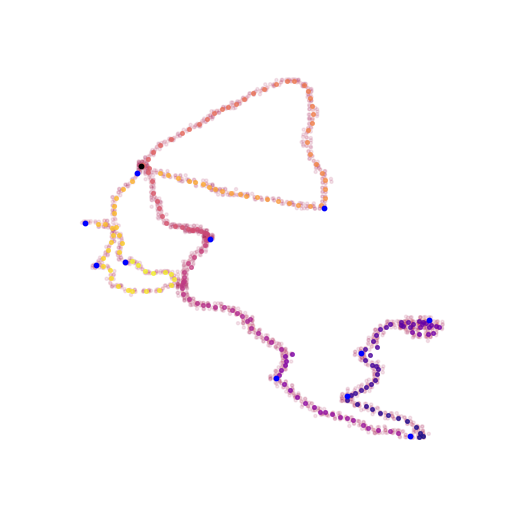

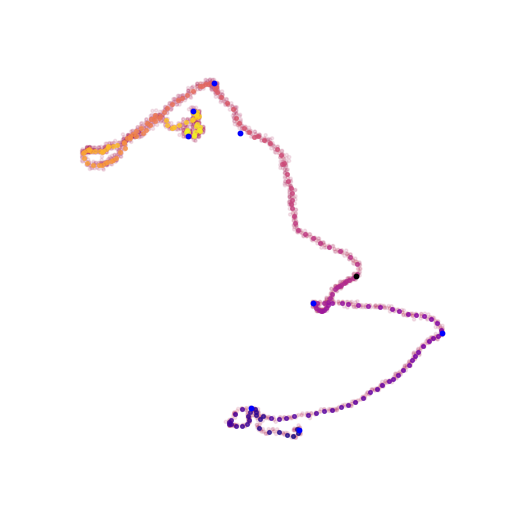

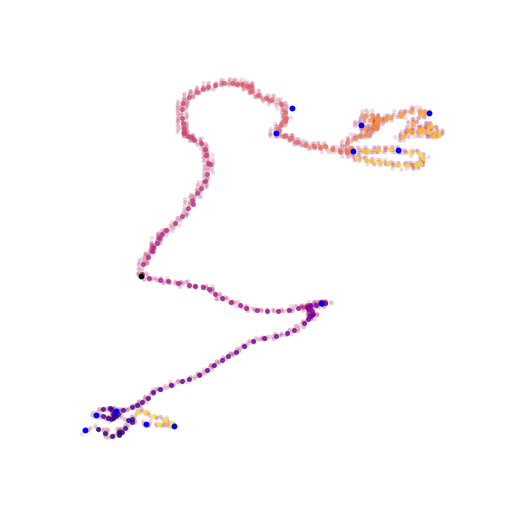

get_data done
Processing event 92884
applied grouping
PlotEvent3D done


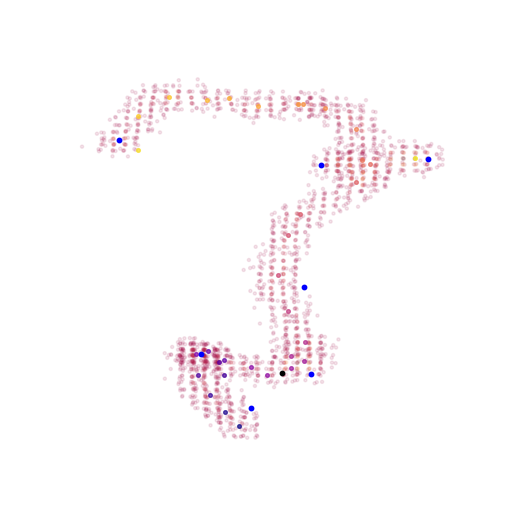

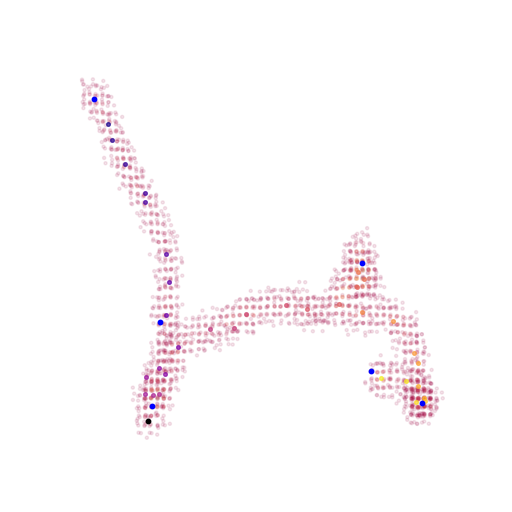

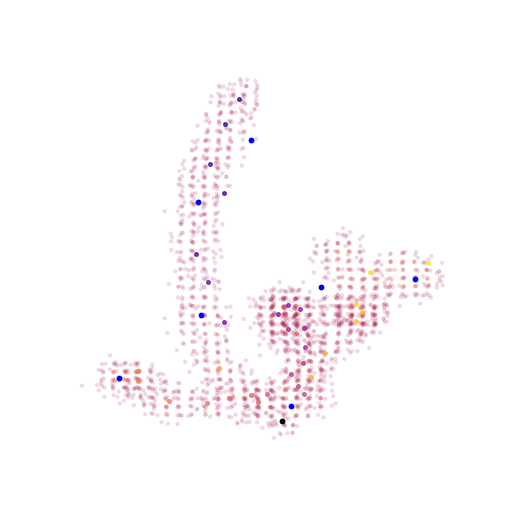

get_data done
Processing event 92885
applied grouping
PlotEvent3D done


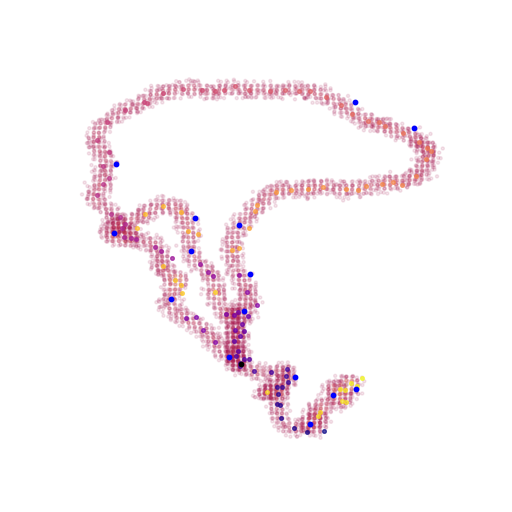

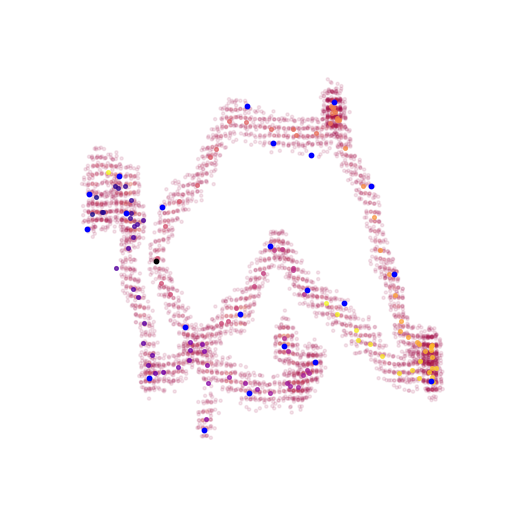

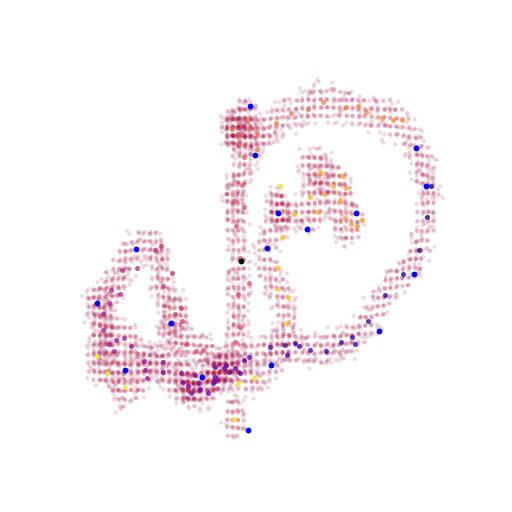

get_data done
Processing event 92886
applied grouping
PlotEvent3D done


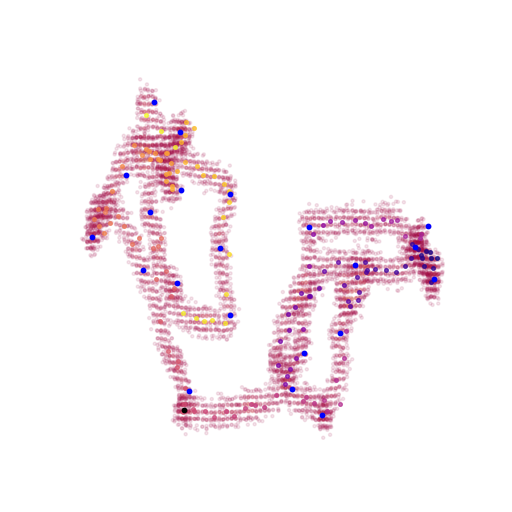

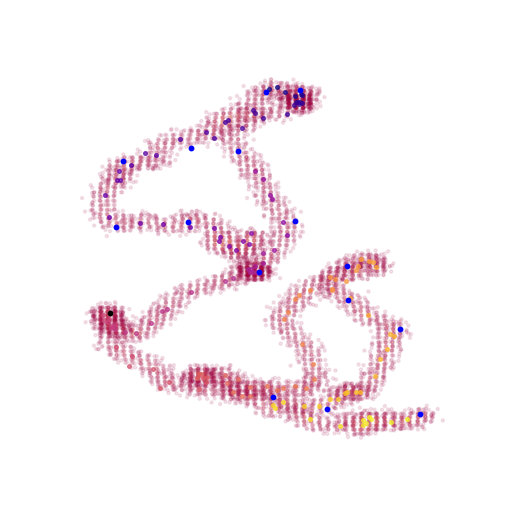

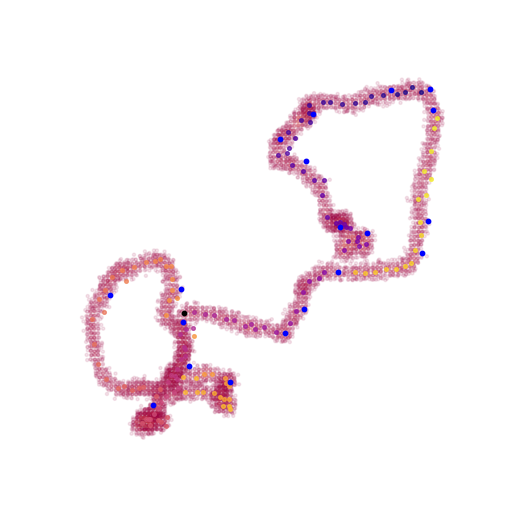

get_data done
Processing event 92887
applied grouping
PlotEvent3D done


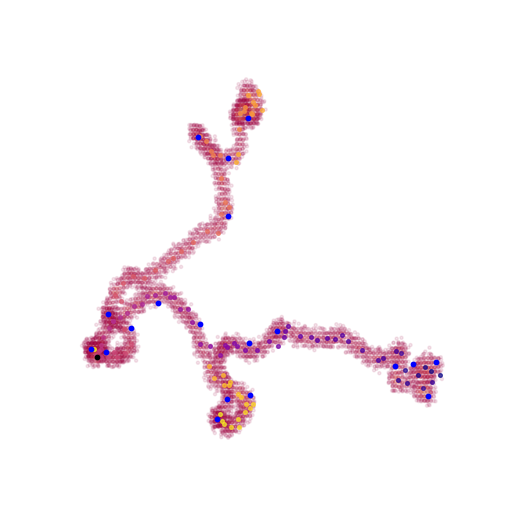

In [ ]:
%matplotlib widget
count = 0
diffusion = "5.0percent"
for eid, group in hits_df.groupby("event_id"):
    if count == 10:
        break
    print(f"Processing event {eid}")
    (XYZC, clustered, vertex) = PlotEvent3D(hits_df, part_df, eid, z_shift, pressure, diffusion)
    print("PlotEvent3D done")
    get_data(XYZC, clustered, vertex, eid, file_identify, split=.1)
    print("get_data done")
    count += 1

applied grouping
Mean sigma group: 14.935666799545288
PlotEvent3D done
i=12, neighbors=6, min_index_sep=4, i_left=8, i_right=16, theta=69.5
i=13, neighbors=7, min_index_sep=4, i_left=9, i_right=17, theta=85.8
i=14, neighbors=7, min_index_sep=4, i_left=10, i_right=18, theta=129.2
i=15, neighbors=7, min_index_sep=4, i_left=11, i_right=19, theta=167.7
i=16, neighbors=6, min_index_sep=4, i_left=12, i_right=20, theta=148.7
i=17, neighbors=5, min_index_sep=3, i_left=14, i_right=20, theta=149.1
i=18, neighbors=6, min_index_sep=4, i_left=14, i_right=22, theta=128.7
i=20, neighbors=6, min_index_sep=4, i_left=16, i_right=24, theta=132.3
i=24, neighbors=7, min_index_sep=4, i_left=20, i_right=28, theta=148.1
i=26, neighbors=6, min_index_sep=4, i_left=22, i_right=30, theta=135.5
i=27, neighbors=6, min_index_sep=4, i_left=23, i_right=31, theta=166.7
i=28, neighbors=5, min_index_sep=3, i_left=25, i_right=31, theta=174.1
i=29, neighbors=5, min_index_sep=3, i_left=26, i_right=32, theta=169.1
i=30, neig

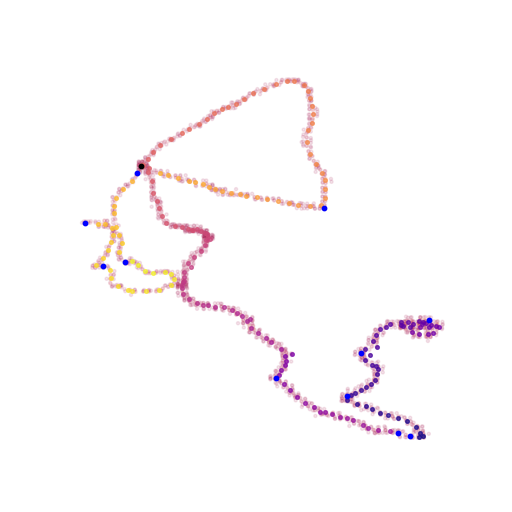

i=8, neighbors=10, min_index_sep=6, i_left=2, i_right=14, theta=158.5
i=9, neighbors=6, min_index_sep=4, i_left=5, i_right=13, theta=169.9
i=10, neighbors=9, min_index_sep=6, i_left=4, i_right=16, theta=102.1
i=11, neighbors=9, min_index_sep=6, i_left=5, i_right=17, theta=79.8
i=12, neighbors=10, min_index_sep=6, i_left=6, i_right=18, theta=61.8
i=13, neighbors=7, min_index_sep=4, i_left=9, i_right=17, theta=63.5
i=14, neighbors=9, min_index_sep=6, i_left=8, i_right=20, theta=102.2
i=15, neighbors=12, min_index_sep=8, i_left=7, i_right=23, theta=115.7
i=16, neighbors=9, min_index_sep=6, i_left=10, i_right=22, theta=144.5
i=17, neighbors=6, min_index_sep=4, i_left=13, i_right=21, theta=102.5
i=18, neighbors=8, min_index_sep=5, i_left=13, i_right=23, theta=81.7
i=19, neighbors=8, min_index_sep=5, i_left=14, i_right=24, theta=47.1
i=20, neighbors=7, min_index_sep=4, i_left=16, i_right=24, theta=55.7
i=21, neighbors=7, min_index_sep=4, i_left=17, i_right=25, theta=52.9
i=22, neighbors=6, m

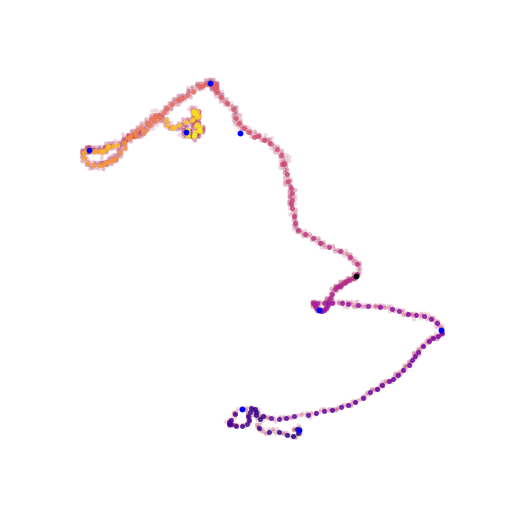

i=8, neighbors=10, min_index_sep=6, i_left=2, i_right=14, theta=84.7
i=9, neighbors=12, min_index_sep=8, i_left=1, i_right=17, theta=24.3
i=10, neighbors=14, min_index_sep=9, i_left=1, i_right=19, theta=40.6
i=14, neighbors=15, min_index_sep=10, i_left=4, i_right=26, theta=112.4
i=22, neighbors=14, min_index_sep=9, i_left=10, i_right=31, theta=79.9
i=23, neighbors=14, min_index_sep=9, i_left=10, i_right=32, theta=79.8
i=24, neighbors=15, min_index_sep=10, i_left=8, i_right=34, theta=102.4
i=25, neighbors=8, min_index_sep=5, i_left=20, i_right=30, theta=152.2
i=26, neighbors=7, min_index_sep=4, i_left=22, i_right=30, theta=142.1
i=27, neighbors=6, min_index_sep=4, i_left=23, i_right=31, theta=154.2
i=28, neighbors=5, min_index_sep=3, i_left=25, i_right=31, theta=176.0
i=52, neighbors=16, min_index_sep=10, i_left=42, i_right=65, theta=42.8
i=53, neighbors=17, min_index_sep=11, i_left=42, i_right=65, theta=37.8
i=54, neighbors=16, min_index_sep=10, i_left=44, i_right=64, theta=44.6
i=55, 

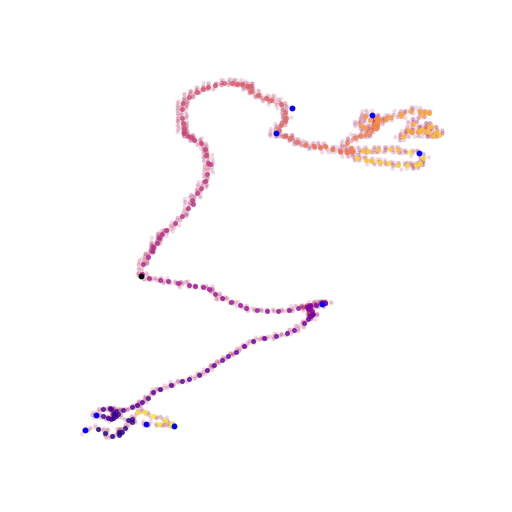

get_data done


In [261]:
(XYZC, clustered, vertex) = PlotEvent3D(hits_df, part_df, 92883, z_shift, pressure, diffusion)
print("PlotEvent3D done")
get_data(XYZC, clustered, vertex, 92883, file_identify, split=.1)
print("get_data done")